In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [25]:
from utils import get_config
config = get_config()

In [26]:
num_classes = config['num_classes']
count_dict = {}
count = 0

data_dir = config['dataset_dir']
p = Path(data_dir)
for file in p.rglob('*'):
    if file.is_file():
        label = file.parent.name
        if label in count_dict:
            count_dict[label] += 1
        else:
            count_dict[label] = 1
        count += 1

count_dict = dict(sorted(count_dict.items(), key=lambda item: item[0], reverse=True))

In [27]:
print(f"Dataset count: {count} images")

Dataset count: 6870 images


In [28]:
plot_dir = Path(config['plot_dir'])
plot_dir.mkdir(parents=True, exist_ok=True)

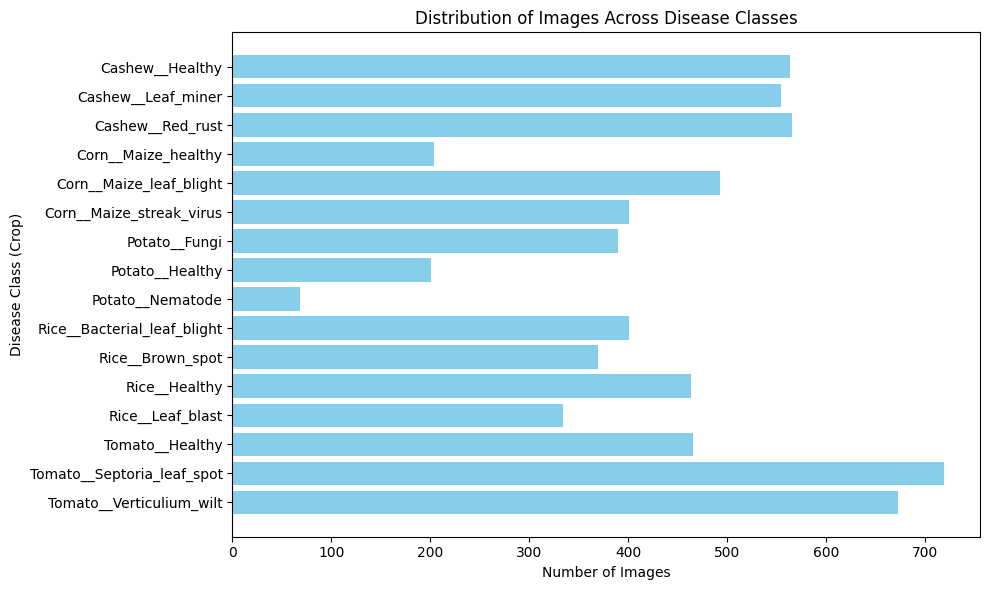

In [29]:
labels = list(count_dict.keys())
counts = list(count_dict.values())

plt.figure(figsize=(10, 6))
plt.barh(labels, counts, color='skyblue')
plt.xlabel('Number of Images')
plt.ylabel('Disease Class (Crop)')
plt.title('Distribution of Images Across Disease Classes')
plt.tight_layout()
plt.savefig(plot_dir / 'class_distribution.png', dpi=300)
plt.show()

In [30]:
import csv
import os

log_dir = config['training_log_dir']
log_name = config['training_log_name']
log_path = os.path.join(log_dir, log_name)
with open(log_path, 'r', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    epochs = []
    train_losses = []
    val_losses = []
    val_accuracies = []
    for row in reader:
        epochs.append(int(row['Epoch']))
        train_losses.append(float(row['Train Loss']))
        val_losses.append(float(row['Validation Loss']))
        val_accuracies.append(float(row['Validation Accuracy']))

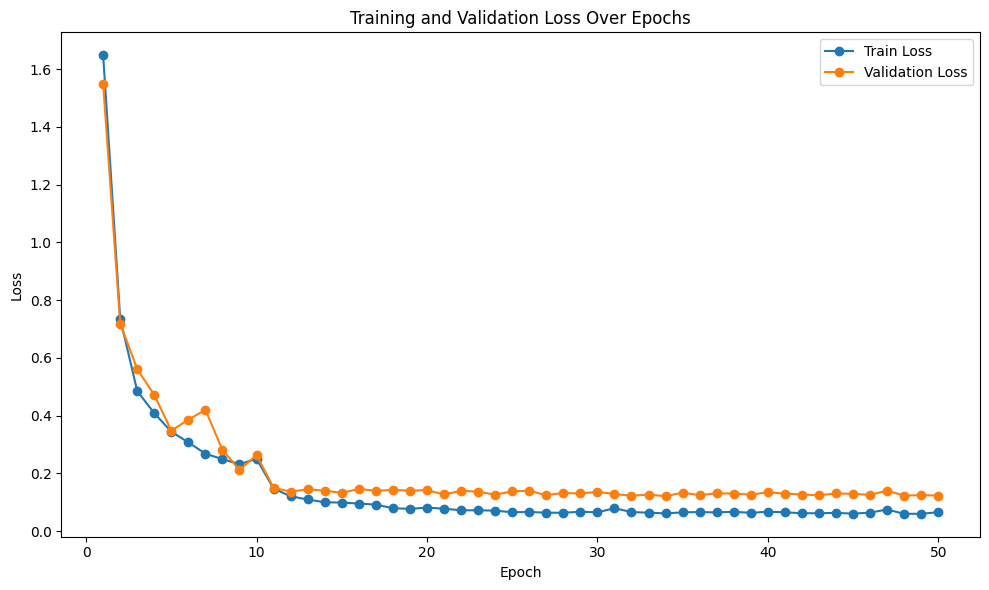

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.tight_layout()
plt.savefig(plot_dir / 'loss_curves.png', dpi=300)
plt.show()

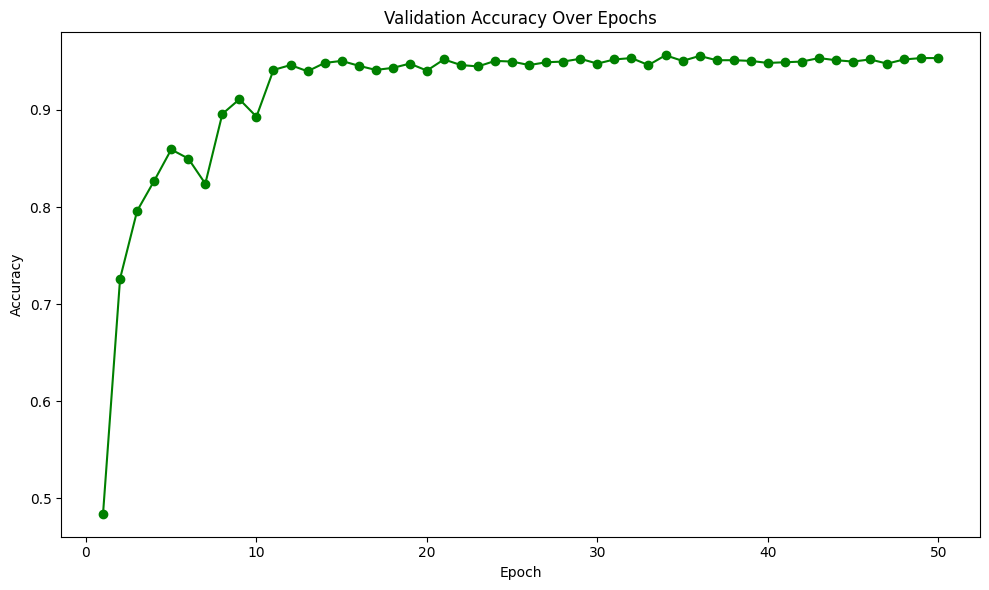

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.tight_layout()
plt.savefig(plot_dir / 'accuracy_curve.png')
plt.show()

In [33]:
import json

report_dir = config['classification_report_dir']
report_name = 'backbone_classification_report.json'
report_path = os.path.join(report_dir, report_name)

with open(report_path, 'r') as f:
    report = json.load(f)

classes = list(report.keys())[:-3]
precisions = [report[cls]['precision'] for cls in classes]
recalls = [report[cls]['recall'] for cls in classes]
f1_scores = [report[cls]['f1-score'] for cls in classes]

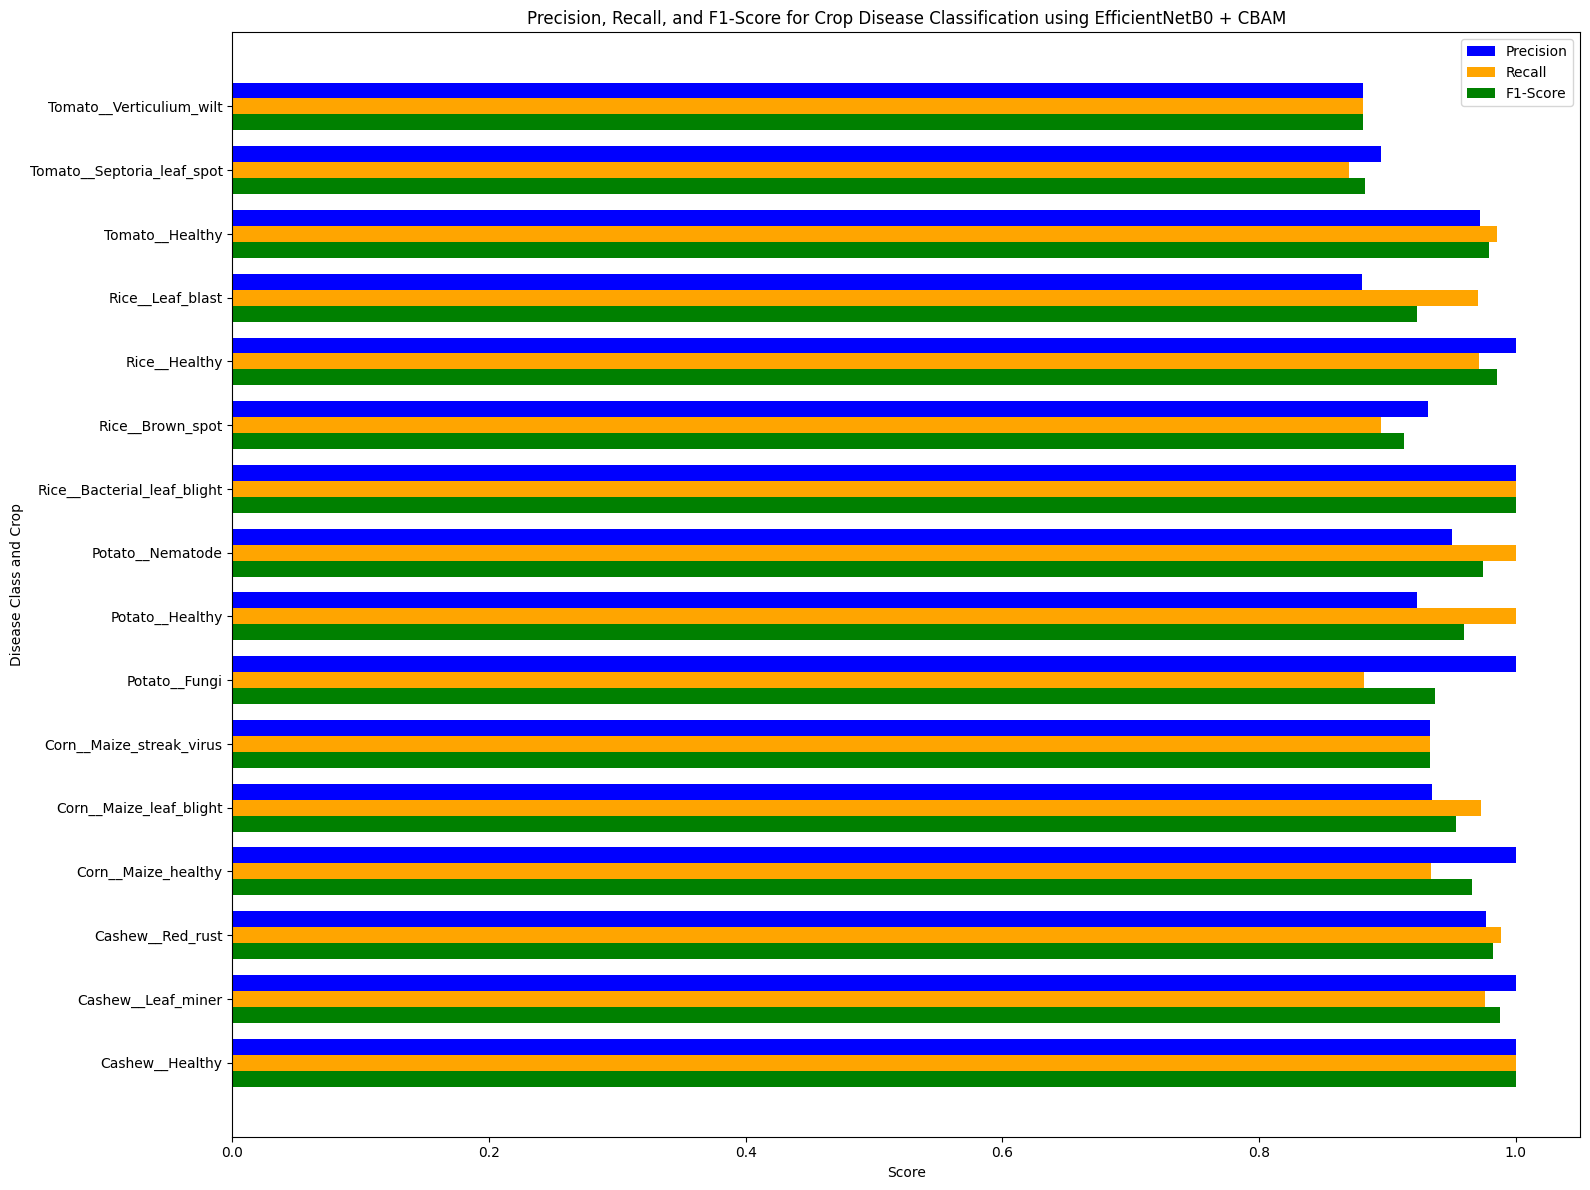

In [34]:
import numpy as np
import matplotlib.pyplot as plt

y = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(16, 12))
plt.barh(y + width, precisions, width, label='Precision', color='blue')
plt.barh(y, recalls, width, label='Recall', color='orange')
plt.barh(y - width, f1_scores, width, label='F1-Score', color='green')
plt.ylabel('Disease Class and Crop')
plt.xlabel('Score')
plt.title('Precision, Recall, and F1-Score for Crop Disease Classification using EfficientNetB0 + CBAM')
plt.yticks(y, classes)
plt.legend()
plt.tight_layout()
plt.savefig(plot_dir / 'classification_report.png')
plt.show()

In [35]:
import json

report_dir = config['classification_report_dir']
report_name = 'svm_classification_report.json'
report_path = os.path.join(report_dir, report_name)

with open(report_path, 'r') as f:
    report = json.load(f)

classes = list(report.keys())[:-3]
precisions = [report[cls]['precision'] for cls in classes]
recalls = [report[cls]['recall'] for cls in classes]
f1_scores = [report[cls]['f1-score'] for cls in classes]

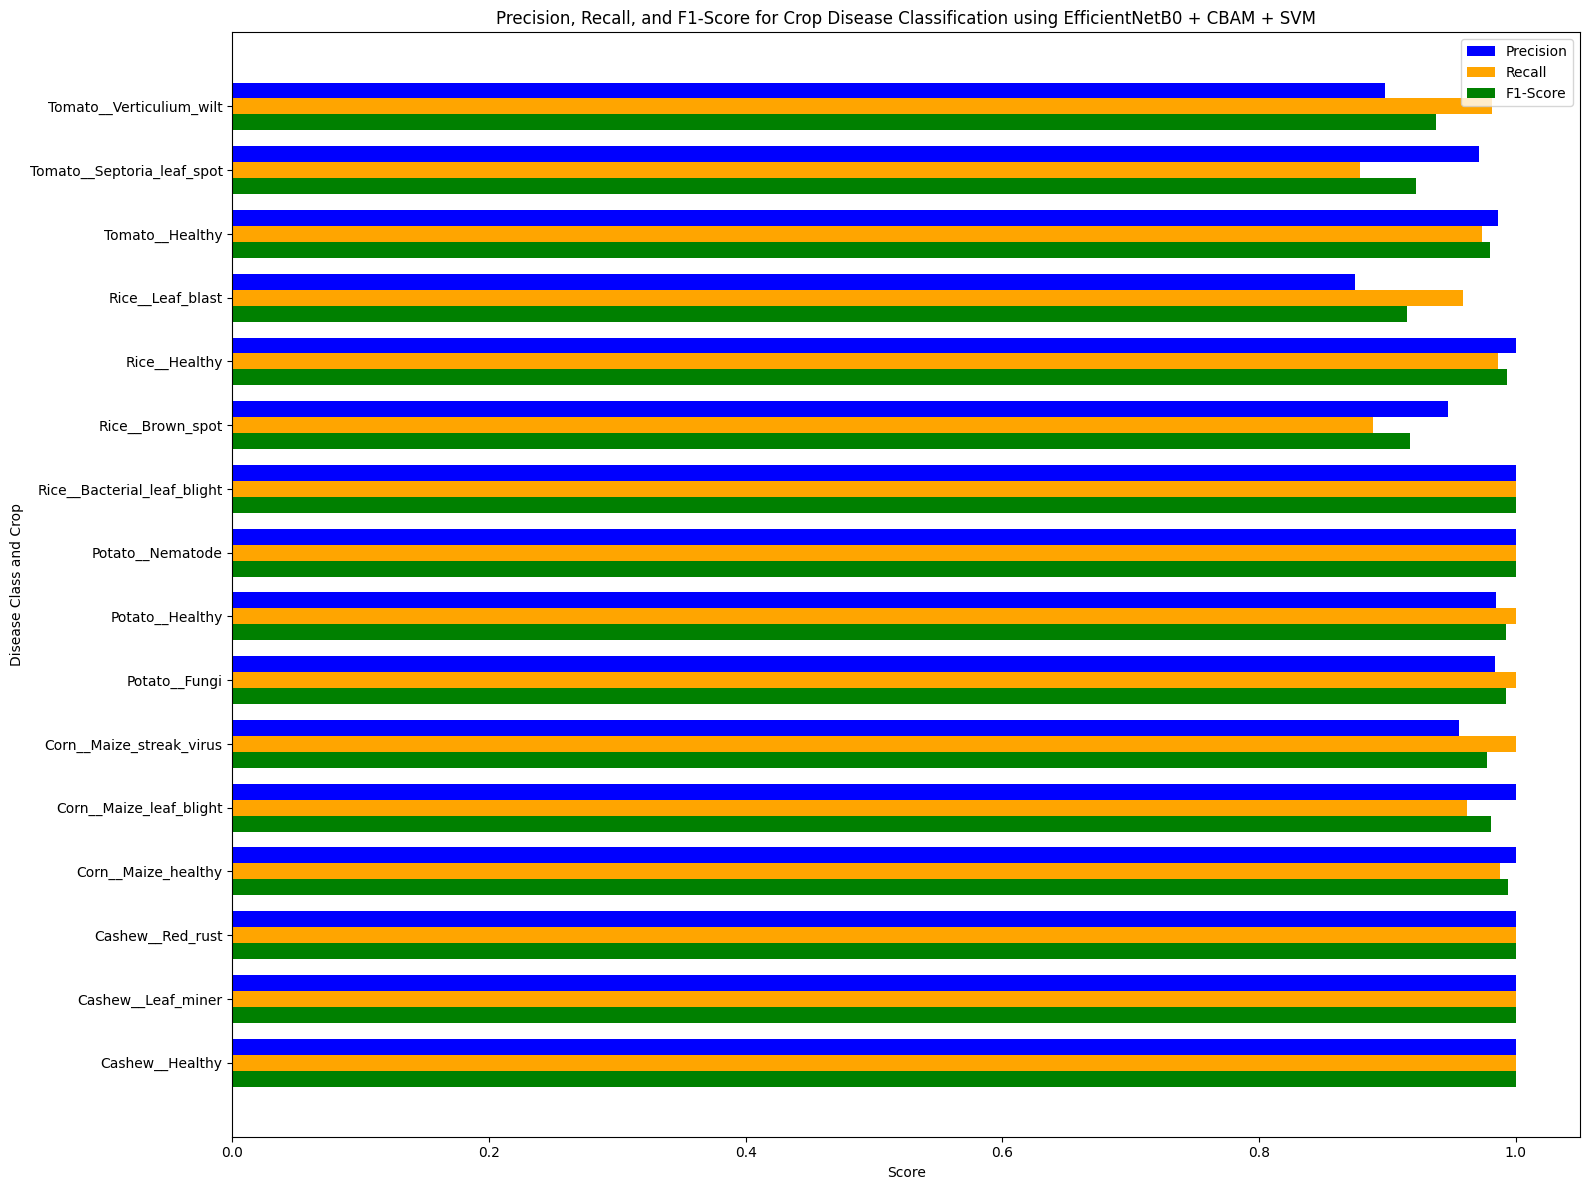

In [36]:
import numpy as np
import matplotlib.pyplot as plt

y = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(16, 12))
plt.barh(y + width, precisions, width, label='Precision', color='blue')
plt.barh(y, recalls, width, label='Recall', color='orange')
plt.barh(y - width, f1_scores, width, label='F1-Score', color='green')
plt.ylabel('Disease Class and Crop')
plt.xlabel('Score')
plt.title('Precision, Recall, and F1-Score for Crop Disease Classification using EfficientNetB0 + CBAM + SVM')
plt.yticks(y, classes)
plt.legend()
plt.tight_layout()
plt.savefig(plot_dir / 'svm_classification_report.png')
plt.show()